<a href="https://colab.research.google.com/github/SilvaPJS/Proceeding-and-Test/blob/main/Testes_com_infer%C3%AAncia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# limpa possíveis conflitos
!pip uninstall -y pycbc emcee lalsuite

Found existing installation: PyCBC 2.10.0
Uninstalling PyCBC-2.10.0:
  Successfully uninstalled PyCBC-2.10.0
Found existing installation: emcee 2.2.1
Uninstalling emcee-2.2.1:
  Successfully uninstalled emcee-2.2.1
Found existing installation: lalsuite 7.26.4
Uninstalling lalsuite-7.26.4:
  Successfully uninstalled lalsuite-7.26.4
  Using cached pycbc-2.10.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (4.6 kB)
  Using cached lalsuite-7.26.4-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.5 kB)
Using cached pycbc-2.10.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (9.4 MB)
Using cached lalsuite-7.26.4-cp312-cp312-manylinux_2_28_x86_64.whl (40.1 MB)
  Using cached emcee-2.2.1-py3-none-any.whl


In [1]:
# instala versões compatíveis
!pip install pycbc
!pip install corner
!pip install "emcee<3.0.0"

In [ ]:
import os
os.kill(os.getpid(), 9)

# Rodar a partir daqui

In [13]:
import numpy as np
from pycbc.catalog import Merger
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.frame import read_frame
from pycbc.filter import highpass, resample_to_delta_t

from pycbc.inference import models
from pycbc.inference.sampler.emcee import EmceeEnsembleSampler

from pycbc.distributions import Uniform, JointDistribution, SinAngle
from astropy.utils.data import download_file

In [14]:
m = Merger("GW170817")

ifos = ['H1', 'L1', 'V1']

data = {}
psds = {}

for ifo in ifos:
    print(f"Processing {ifo}")

    url = "https://dcc.ligo.org/public/0146/P1700349/001/{}-{}1_LOSC_CLN_4_V1-1187007040-2048.gwf"
    fname = download_file(url.format(ifo[0], ifo[0]), cache=True)

    ts = read_frame(fname, f"{ifo}:LOSC-STRAIN",
                    start_time=int(m.time - 260),
                    end_time=int(m.time + 40))

    ts = highpass(ts, 15.0)
    ts = resample_to_delta_t(ts, 1.0/2048)
    ts = ts.time_slice(m.time-112, m.time+16)

    data[ifo] = ts.to_frequencyseries()

    psd = interpolate(ts.psd(4), ts.delta_f)
    psd = inverse_spectrum_truncation(
        psd,
        int(4 * psd.sample_rate),
        trunc_method='hann',
        low_frequency_cutoff=20.0
    )

    psds[ifo] = psd

Processing H1
Processing L1
Processing V1


In [15]:
static = {
    'mass1': 1.3757,
    'mass2': 1.3757,
    'f_lower': 25.0,
    'approximant': "TaylorF2",
    'polarization': 0,
    'ra': 3.44615914,
    'dec': -0.40808407
}

variable = ('distance', 'inclination', 'tc')

prior = JointDistribution(
    variable,
    SinAngle(inclination=None),
    Uniform(distance=(10, 100)),
    Uniform(tc=(m.time-0.1, m.time+0.1))
)

In [19]:
import copy

model = models.SingleTemplate(
    variable,
    copy.deepcopy(data),
    low_frequency_cutoff={'H1':25, 'L1':25, 'V1':25},
    psds=psds,
    static_params=static,
    prior=prior,
    sample_rate=2048
)

engine = EmceeEnsembleSampler(
    model,
    nwalkers=200,
    nprocesses=2
)

In [20]:
# gera amostras do prior
p0_field = prior.rvs(size=200)

# converte FieldArray -> numpy array
p0 = np.column_stack([p0_field[v] for v in variable])

In [21]:
engine._sampler.run_mcmc(p0, 2000)

(array([[2.12799517e+01, 2.04766905e+00, 1.18700888e+09],
        [1.59594570e+01, 1.91319785e+00, 1.18700888e+09],
        [4.65888537e+01, 1.68756962e-01, 1.18700888e+09],
        [3.99713296e+01, 6.52374501e-01, 1.18700888e+09],
        [4.69254738e+01, 4.31228264e-01, 1.18700888e+09],
        [6.83280483e+01, 1.57250007e+00, 1.18700888e+09],
        [5.05914331e+01, 1.53125113e+00, 1.18700888e+09],
        [1.78741512e+01, 1.94030378e+00, 1.18700888e+09],
        [4.66815340e+01, 3.18446991e-01, 1.18700888e+09],
        [2.38982509e+01, 2.07747016e+00, 1.18700888e+09],
        [5.39792849e+01, 1.18746354e-01, 1.18700888e+09],
        [4.62206276e+01, 3.68814623e-01, 1.18700888e+09],
        [4.12599681e+01, 5.85862829e-01, 1.18700888e+09],
        [4.94428378e+01, 4.47972807e-01, 1.18700888e+09],
        [2.77806437e+01, 2.18896144e+00, 1.18700888e+09],
        [4.88337847e+01, 3.63163700e-01, 1.18700888e+09],
        [4.75000678e+01, 1.89317421e-01, 1.18700888e+09],
        [5.026

In [22]:
import numpy as np

samples = engine._sampler.flatchain

# separa parâmetros
distance = samples[:, 0]
inclination = samples[:, 1]
tc = samples[:, 2]

print(samples.shape)

(400000, 3)


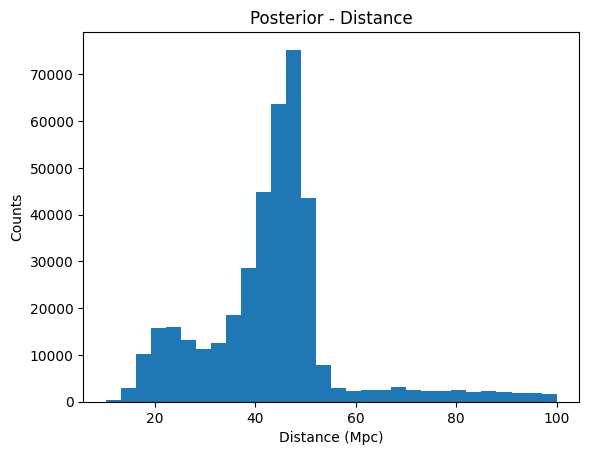

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(distance, bins=30)
plt.xlabel("Distance (Mpc)")
plt.ylabel("Counts")
plt.title("Posterior - Distance")
plt.show()

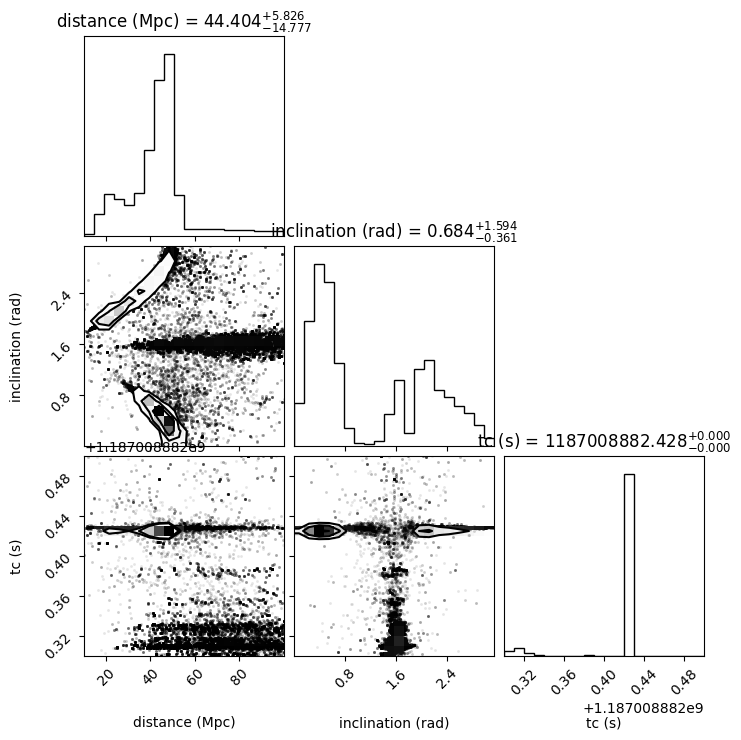

In [24]:
import corner

corner.corner(
    samples,
    labels=["distance (Mpc)", "inclination (rad)", "tc (s)"],
    show_titles=True,
    title_fmt=".3f"
)
plt.show()